In [1]:
# Import các thư viện
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from keras.models import Sequential

from PIL import Image
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import shutil
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

In [2]:
# mount vào drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Đường dẫn file zip (lưu trong Google Drive)
zip_path = "/content/drive/MyDrive/Datasets/X-ray.zip"

# Thư mục đích giải nén trên Colab (local)
extract_path = "/content/X-ray"
# Giải nén dataset vào Colab local
!unzip -q "$zip_path" -d "$extract_path"


replace /content/X-ray/X-ray/test/NORMAL/IM-0001-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [4]:
# Khai báo và kiểm tra đường dẫn
import pathlib

data_dir = pathlib.Path("/content/X-ray/X-ray")

data_dir_train = data_dir / "train"
data_dir_validation = data_dir / "val"
data_dir_test = data_dir / "test"

print("Train:", data_dir_train)
print("Val  :", data_dir_validation)
print("Test :", data_dir_test)

Train: /content/X-ray/X-ray/train
Val  : /content/X-ray/X-ray/val
Test : /content/X-ray/X-ray/test


In [5]:
# Thiết lập kích thước ảnh, batch size và tạo tập dữ liệu huấn luyện (train_ds)
img_height,img_width=180, 180
batch_size=32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 5216 files belonging to 2 classes.


In [6]:
# Tạo tập dữ liệu validation (val_ds)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_validation,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 16 files belonging to 2 classes.


In [7]:
# Tạo tập dữ liệu test để đánh giá mô hình
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_test,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 624 files belonging to 2 classes.


In [8]:
# Kiểm tra số lượng ảnh trong từng thư mục
print("Train dir:", data_dir_train)
print("Val dir  :", data_dir_validation)
print("Test dir :", data_dir_test)

print("Train classes:", train_ds.class_names)

import os, glob

def count_imgs(p):
    return len(glob.glob(os.path.join(str(p), "*", "*")))

print("Train images:", count_imgs(data_dir_train))
print("Val images  :", count_imgs(data_dir_validation))
print("Test images :", count_imgs(data_dir_test))

Train dir: /content/X-ray/X-ray/train
Val dir  : /content/X-ray/X-ray/val
Test dir : /content/X-ray/X-ray/test
Train classes: ['NORMAL', 'PNEUMONIA']
Train images: 5216
Val images  : 16
Test images : 624


In [9]:
# Bảng thống kê số lượng ảnh theo từng lớp trong train/val/test
import os, glob
import pandas as pd

def count_per_class(split_dir):
    classes = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
    counts = {c: len(glob.glob(os.path.join(split_dir, c, "*"))) for c in classes}
    counts["TOTAL"] = sum(counts.values())
    return counts

rows = []
for name, split_path in [("Train", data_dir_train), ("Val", data_dir_validation), ("Test", data_dir_test)]:
    c = count_per_class(str(split_path))
    c["Split"] = name
    rows.append(c)

df_counts = pd.DataFrame(rows).set_index("Split")
df_counts

,NORMAL,PNEUMONIA,TOTAL
Split,,,
Train,1341,3875,5216
Val,8,8,16
Test,234,390,624


from matplotlib import pyplot as plt
df_counts['NORMAL'].plot(kind='hist', bins=20, title='NORMAL')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_counts['PNEUMONIA'].plot(kind='hist', bins=20, title='PNEUMONIA')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_counts['TOTAL'].plot(kind='hist', bins=20, title='TOTAL')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_counts.plot(kind='scatter', x='NORMAL', y='PNEUMONIA', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_counts.plot(kind='scatter', x='PNEUMONIA', y='TOTAL', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_counts['NORMAL'].plot(kind='line', figsize=(8, 4), title='NORMAL')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df_counts['PNEUMONIA'].plot(kind='line', figsize=(8, 4), title='PNEUMONIA')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df_counts['TOTAL'].plot(kind='line', figsize=(8, 4), title='TOTAL')
plt.gca().spines[['top', 'right']].set_visible(False)

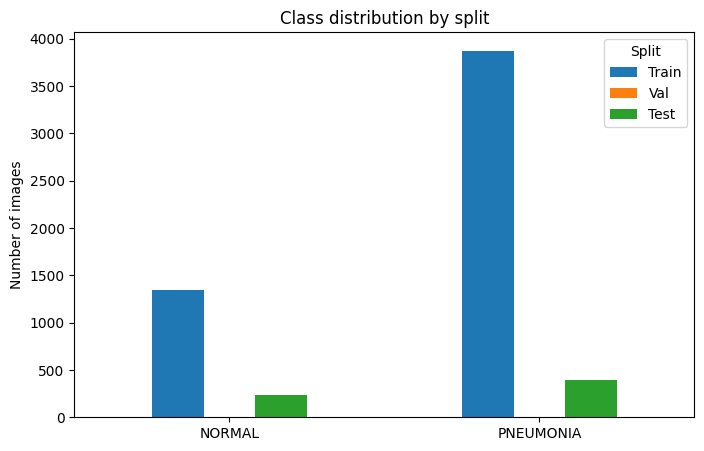

In [10]:
# Vẽ biểu đồ cột phân bố số lượng ảnh theo lớp (train/val/test)
import matplotlib.pyplot as plt

df_plot = df_counts.drop(columns=["TOTAL"])
df_plot.T.plot(kind="bar", figsize=(8,5))
plt.title("Class distribution by split")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Kiểm tra dataset (kiểm tra các file không phải ảnh hoặc không được hỗ trợ)
from pathlib import Path
import imghdr

# Đường dẫn dataset
data_dir = Path("/content/X-ray/X-ray") # Updated to reflect correct extraction path

# Các đuôi file ảnh chấp nhận
image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}

# Các định dạng TensorFlow đọc được
img_type_accepted_by_tf = {"bmp", "gif", "jpeg", "png"}

bad_files = 0

for filepath in data_dir.rglob("*"):
    if filepath.is_file() and filepath.suffix.lower() in image_extensions:
        try:
            img_type = imghdr.what(filepath)
            if img_type is None:
                print(f"Not an image: {filepath}")
                bad_files += 1
            elif img_type not in img_type_accepted_by_tf:
                print(f"Unsupported type {img_type}: {filepath}")
                bad_files += 1
        except Exception as e:
            print(f"Error processing {filepath}: {e}")
            bad_files += 1

print(f"\nDone. Found {bad_files} problematic files.")


Done. Found 0 problematic files.


/tmp/ipython-input-3628495772.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [12]:
# Tăng tốc pipeline dữ liệu bằng cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
# Kiểm tra các lớp (nhãn)
class_names = ['NORMAL', 'PNEUMONIA']
print(class_names)

['NORMAL', 'PNEUMONIA']


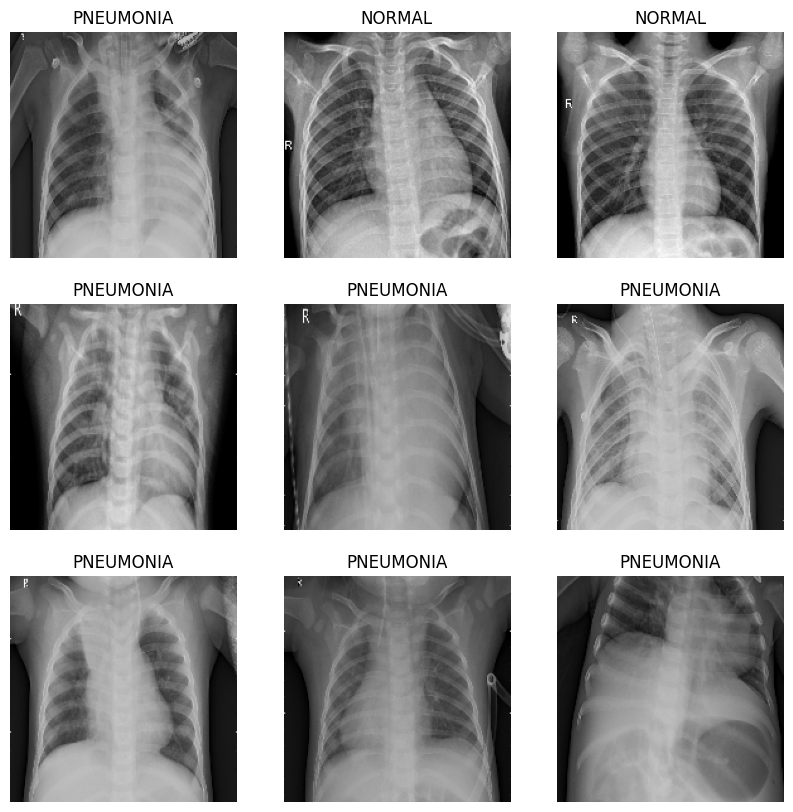

In [27]:
# Hiển thị ngẫu nhiên 9 ảnh từ tập huấn luyện cùng với nhãn tương ứng để trực quan hóa dữ liệu trước khi train
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [15]:
# Xây dựng mô hình CNN
num_classes = 2

model = Sequential([
  layers.Input(shape=(img_height, img_width, 3)),
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes,activation='softmax')
])

In [16]:
# Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [17]:
# Huấn luyện mô hình trên tập train và đánh giá trên tập val
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8485 - loss: 0.3496 - val_accuracy: 0.6250 - val_loss: 0.9230
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9680 - loss: 0.0926 - val_accuracy: 0.6875 - val_loss: 0.8435
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9755 - loss: 0.0647 - val_accuracy: 0.8750 - val_loss: 0.2686
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9791 - loss: 0.0570 - val_accuracy: 0.8750 - val_loss: 0.2457
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9873 - loss: 0.0361 - val_accuracy: 0.8750 - val_loss: 0.3436
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9897 - loss: 0.0244 - val_accuracy: 0.8125 - val_loss: 0.3035
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9912 - loss: 0.0240 - val_accuracy: 0.9375 - val_loss: 0.1205
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9969 - loss: 0.0121 - val_acc

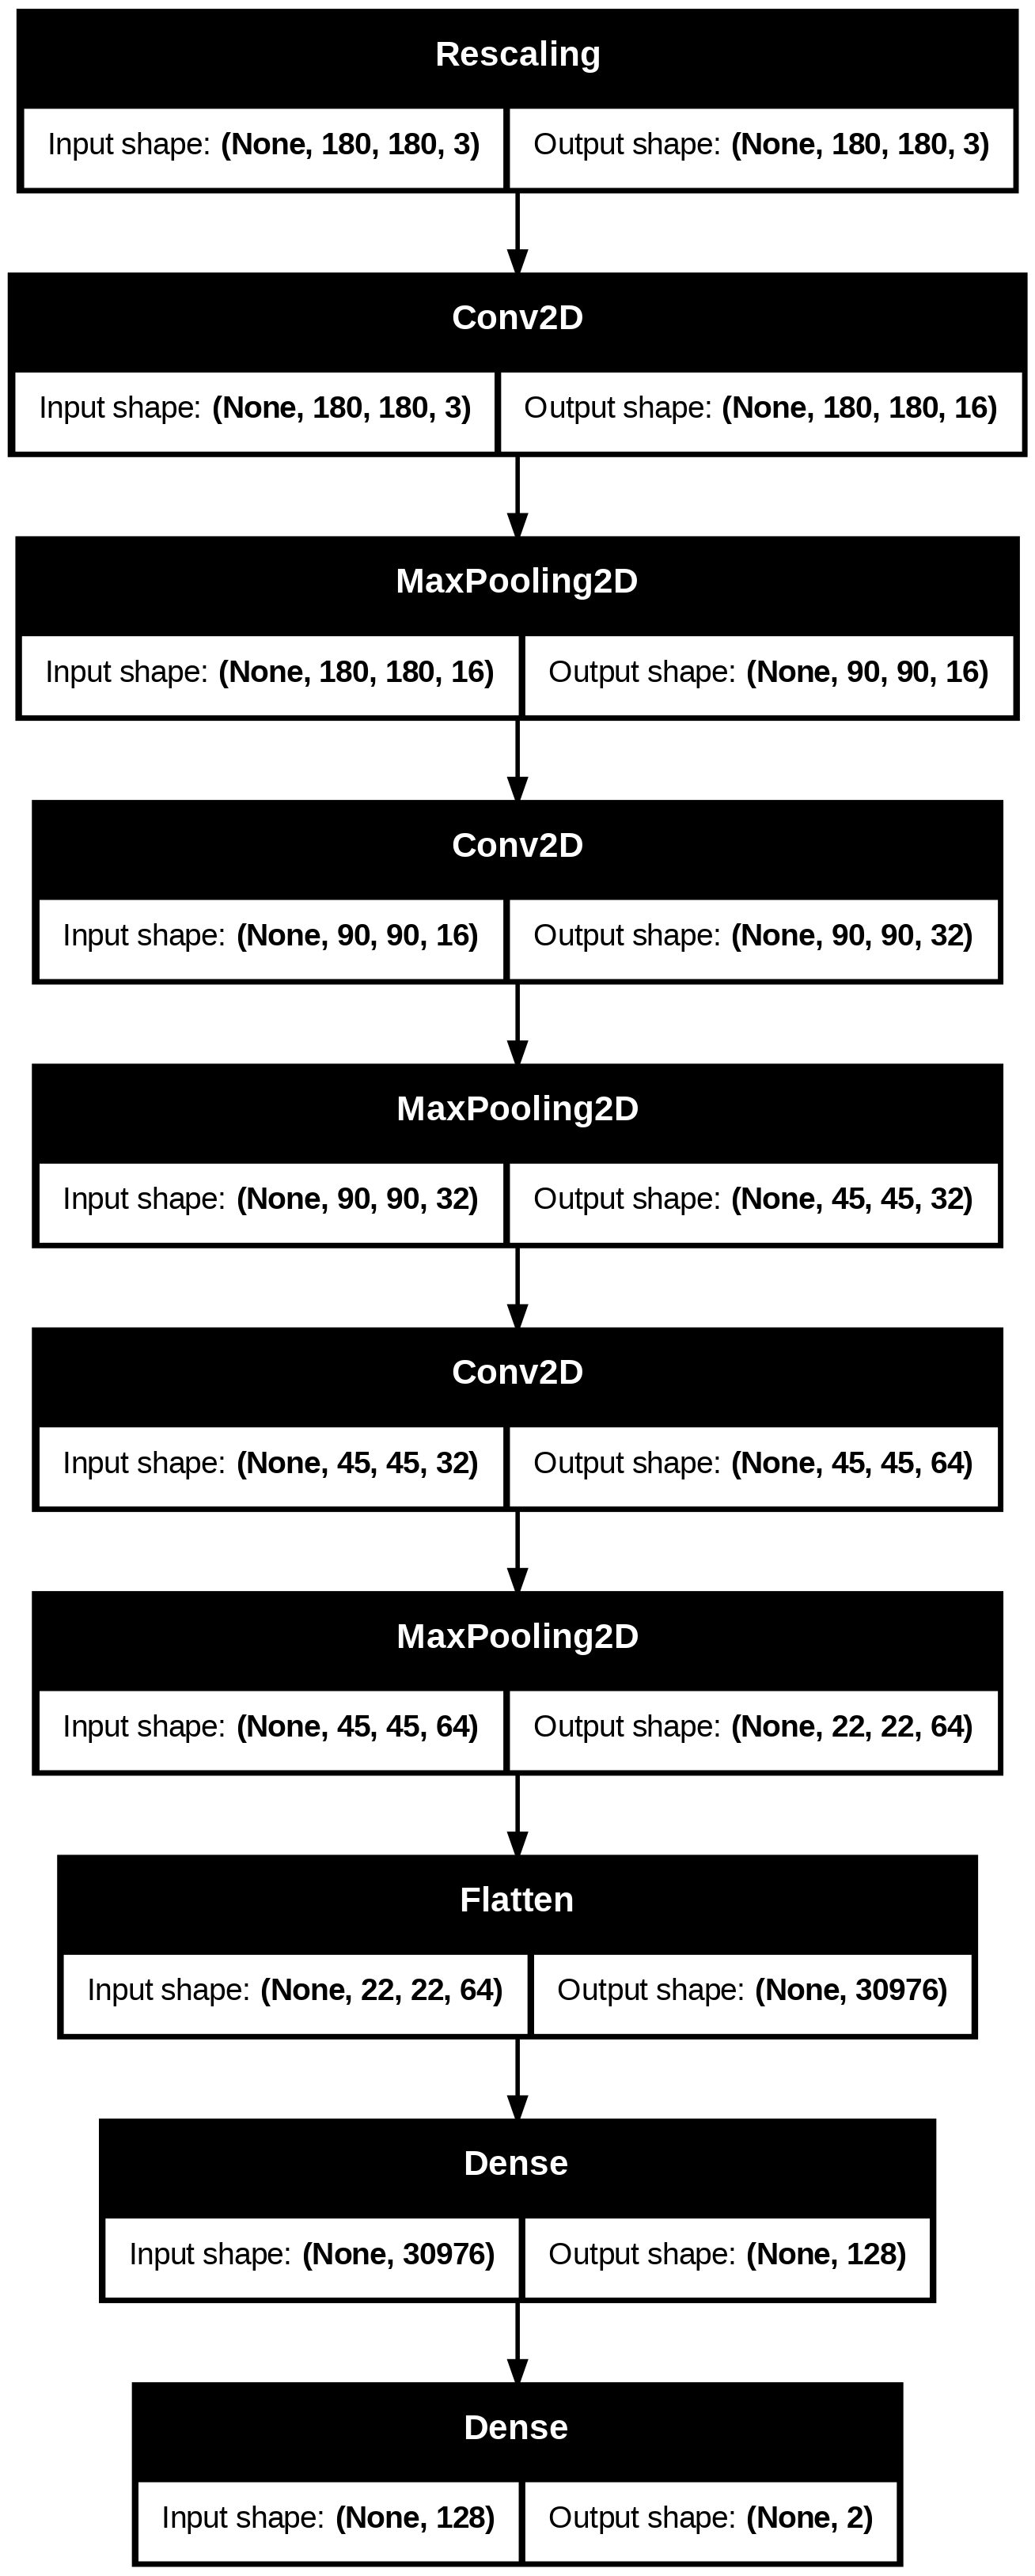

In [18]:
# sơ đồ kiến trúc của mô hình Keras
keras.utils.plot_model(model, show_shapes=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


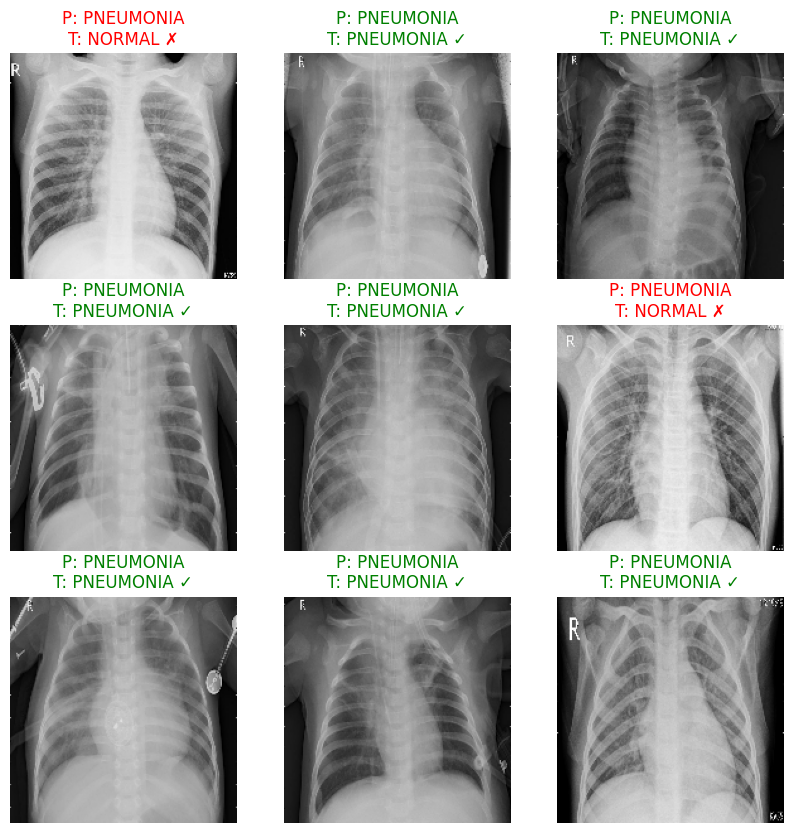

In [28]:
# Demo test: dự đoán 9 ảnh từ tập test và so sánh với nhãn thật
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        pred_label = class_names[np.argmax(predictions[i])]
        true_label = class_names[labels[i]]

        # Đánh dấu đúng / sai
        color = "green" if pred_label == true_label else "red"
        symbol = "✓" if pred_label == true_label else "✗"

        plt.title(f"P: {pred_label}\nT: {true_label} {symbol}", color=color)
        plt.axis("off")

plt.show()

In [20]:
# Đánh giá mô hình trên tập test
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.7901 - loss: 1.7710
Test accuracy: 0.7852563858032227


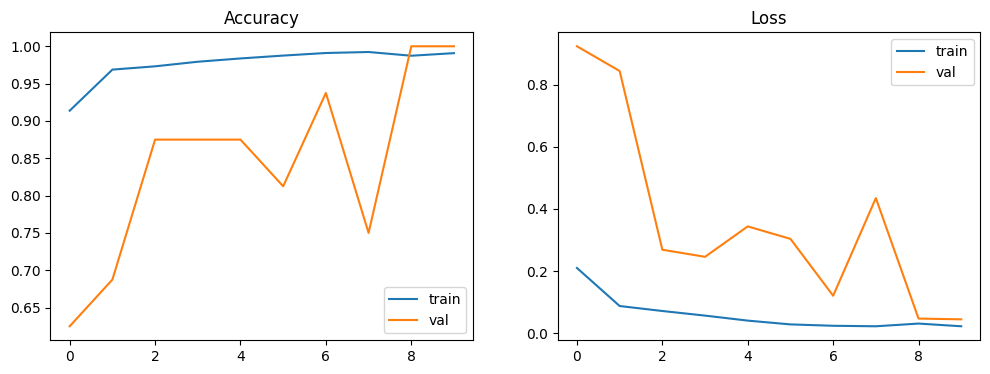

In [21]:
# Vẽ biểu đồ accuracy và loss theo epoch (quan sát mô hình có overfit/underfit không)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.show()

In [22]:
# Đánh giá chi tiết bằng confusion matrix và classification report
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Confusion matrix:
 [[106 128]
 [  6 384]]

Classification report:
               precision    recall  f1-score   support

      NORMAL       0.95      0.45      0.61       234
   PNEUMONIA       0.75      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.85      0.72      0.73       624
weighted avg       0.82      0.79      0.76       624



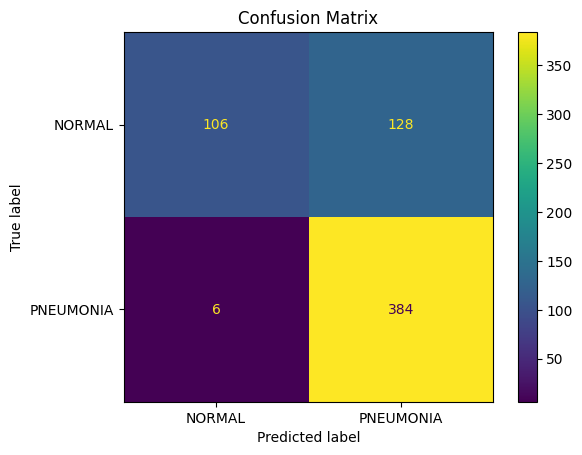

In [23]:
# Vẽ confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [24]:
# Bảng tổng hợp các chỉ số đánh giá
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

summary = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
}

df_metrics = pd.DataFrame([summary])
df_metrics

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,0.785256,0.848214,0.718803,0.732079


In [30]:
# lưu model vào Drive
model.save("/content/drive/MyDrive/xray_model.keras")